## Archival publication note

This copy preserves the submitted calculations and historical outputs. Local paths were made relative for publication. Read [README](README.md) and [AUDIT](../../AUDIT.md) before interpreting results. Edited original cell indices: [14, 23, 27, 32, 37, 40, 42]. No fresh execution is claimed.


<img src='sharif.png' alt="SUT logo" width=200 height=200 align=left class="saturate" >


<br>
<font>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Machine Learning <br>
<font color=2565AE size=5>
    Electrical Engineering Department <br>
    spring 2026<br>
<font color=3C99D size=5>
    Practical Assignment 5 - Unsupervised Learning<br>
<font color=696880 size=4>
     Professor : Sajad Amini <br>
<font color=696880 size=5>
     designer : Mohammad Reza Monemian


### Full Name :
### Student Number :
___
For further questions, Contact Teaching Assistant: <br>
Telegram: @Mohammad_reza_1827_Mn <br>
Bale: @mohammadmn84 <br>
___

In [2]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster

<font color=red size=3>
notice that you can not use sklearn.decomposition and sklearn.cluster libary in this home work! you should implement pca and kmeans from scratch.

## Overview
In this assignment, you will perform PCA and K-Means clustering on credit card customer data. dataset contains information about customer’s use of credit cards. The goal is to reduce the dataset’s dimensionality using PCA and then apply clustering to segment customers. You will compare the clustering performance both before and after PCA. Additionally, you'll be asked to explain the theory and decisions behind each step.

## Data Preprocessing (15 points)
Read the dataset.CSV file and display a few samples.

In [3]:
df = pd.read_csv("dataset.csv")
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


Display dataset information.

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


Which column do you think might be the most irrelevant for PCA and clustering?
<br>
Answer: 

In [5]:
# Exclude irrelevant feature
df = df.drop(columns=["CUST_ID"])

how do you handle missing data, and why did you choose this method?
<br>
Answer: 


In [6]:
#Fill missing data
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())

plot the correlation matrix and identify redundant features.remove them from the dataframe.

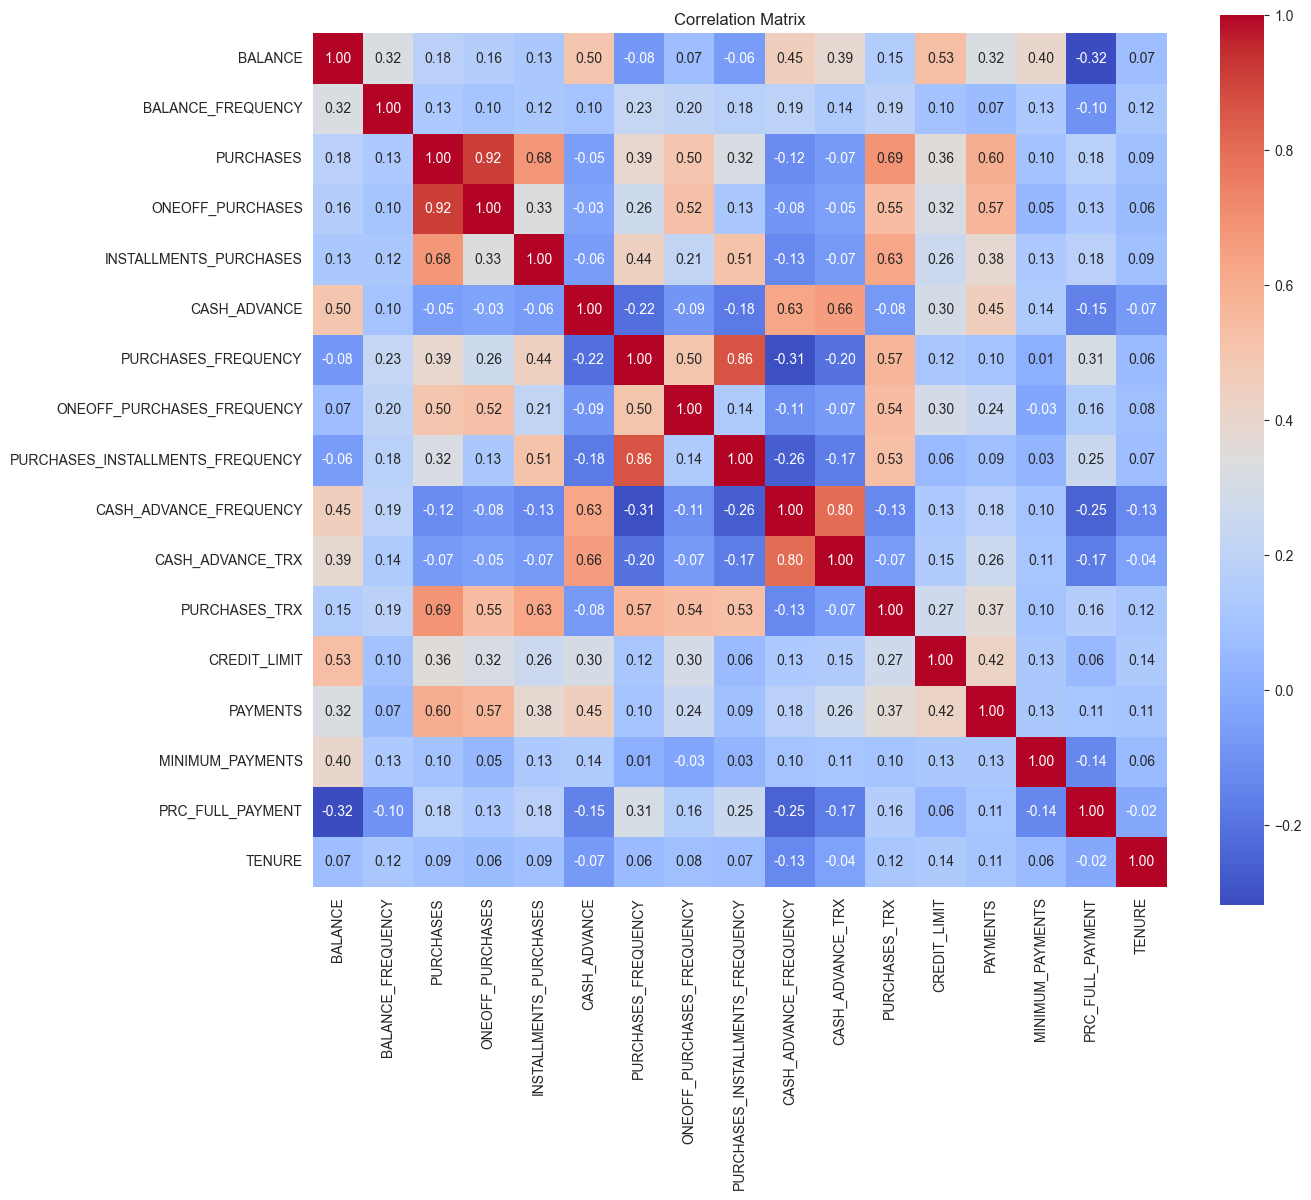

In [7]:
# Plot the correlation matrix
plt.figure(figsize=(14, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(r"correlation_matrix.png")
plt.show()

In [8]:
# Identify and remove redundant features. use 0.8 threshold.
threshold = 0.8
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
redundant_features = [col for col in upper.columns if any(upper[col] > threshold)]
print("Redundant features to drop:", redundant_features)
df = df.drop(columns=redundant_features)
print(df.shape)

Redundant features to drop: ['ONEOFF_PURCHASES', 'PURCHASES_INSTALLMENTS_FREQUENCY']
(8950, 15)


## Standardize the Data (5 points)
Standardize the dataset using z-score normalization

In [9]:
# todo
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
df_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.349079,-0.466786,-0.806490,-0.678661,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.454576,2.605605,-1.221758,-0.678661,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,-0.454576,-0.466786,1.269843,2.673451,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,-0.454576,-0.368653,-1.014125,-0.399319,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.454576,-0.466786,-1.014125,-0.399319,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


Why is it important to standardize the data before applying PCA?
<br>
Answer:

PCA finds principal components based on the variance of the data. If features
have different scales (e.g., BALANCE in the thousands vs. PURCHASES_FREQUENCY
between 0 and 1), features with larger numeric ranges will artificially
dominate the variance and therefore dominate the principal components, even
if they are not more informative. Standardizing the data (z-score
normalization) rescales every feature to have mean 0 and standard deviation
1, so PCA captures the true correlation structure between variables instead
of being biased by their original units/scales.

What is differnce between Normalizer and StandardScaler classes. which is better for PCA?
<br>
Answer:

StandardScaler operates column-wise (per feature): it rescales each feature
to have mean 0 and standard deviation 1 (z-score normalization).
Normalizer operates row-wise (per sample): it rescales each sample's feature
vector so that its norm (e.g., L2 norm) equals 1, preserving the direction
of the sample vector but changing its magnitude.

For PCA, StandardScaler is the better choice, since PCA relies on the
variance/covariance structure across features. Normalizer distorts this
structure by normalizing across samples instead of features, making it
unsuitable for PCA preprocessing.

## Principal Component Analysis (PCA) (35 points)
Implement PCA from scratch.

In [10]:
import numpy as np


class CustomPCA:
    def __init__(self, n_components=None):
        """
        Initialize the PCA class with the number of components to keep.
        n_components: Number of principal components to keep. If None, all components are kept.
        """
        self.n_components = n_components
        self.components = None  # To store the principal components (eigenvectors)
        self.mean = None  # To store the mean of the data (used for centering the data)
        self.explained_variance_ratio = None  # To store the explained variance ratio of the components

    def fit(self, X):
        """
        Fit the PCA model on the dataset X by calculating the eigenvalues and eigenvectors of the covariance matrix.
        X: Input data (n_samples, n_features)
        """
        X = np.array(X)
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # covariance matrix (features x features)
        cov_matrix = np.cov(X_centered, rowvar=False)

        # eigen decomposition (cov_matrix is symmetric -> eigh)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # eigh returns ascending order -> sort descending
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]

        n_components = self.n_components if self.n_components is not None else X.shape[1]

        self.components = eigenvectors[:, :n_components]
        total_variance = np.sum(eigenvalues)
        self.explained_variance_ratio = eigenvalues[:n_components] / total_variance

    def transform(self, X):
        """
        Transform the input data X into the new space using the principal components.
        X: Input data (n_samples, n_features)
        """
        X = np.array(X)
        X_centered = X - self.mean
        # Return the transformed data
        return np.dot(X_centered, self.components)

    def get_explained_variance_ratio(self):
        """
        Return the explained variance ratio of each principal component.
        """
        return self.explained_variance_ratio

    def get_components(self):
        """
        Return the principal components (eigenvectors).
        """
        return self.components

### Visualizing the Cumulative Variance

Plot the cumulative explained variance to visualize the selection of components.  How many components are needed to explain 75% of the variance?
<br>
answer:

6 components

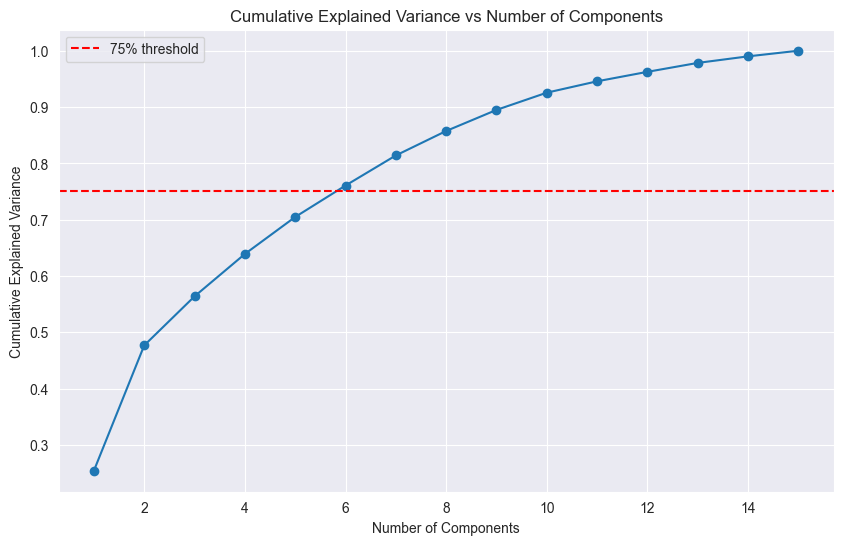

Number of components needed for 75% variance: 6
Cumulative variance ratios: [0.2541083  0.47661703 0.56375628 0.63899948 0.70469992 0.76058004
 0.8140162  0.85745353 0.89487545 0.92550348 0.94569795 0.96250476
 0.97837154 0.99000092 1.        ]


In [11]:
pca_full = CustomPCA(n_components=df_scaled.shape[1])
pca_full.fit(df_scaled.values)

explained_var_ratio = pca_full.get_explained_variance_ratio()
cumulative_var = np.cumsum(explained_var_ratio)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')
plt.axhline(y=0.75, color='r', linestyle='--', label='75% threshold')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance vs Number of Components")
plt.legend()
plt.grid(True)
plt.savefig(r"cumulative_variance.png")
plt.show()

n_components_75 = np.argmax(cumulative_var >= 0.75) + 1
print("Number of components needed for 75% variance:", n_components_75)
print("Cumulative variance ratios:", cumulative_var)

Build a new DataFrame with the first slected components. save it to a new CSV file named 'pca_output.csv'

In [13]:
#Build a new DataFrame with the first slected components
n_components = n_components_75  # from previous step

pca = CustomPCA(n_components=n_components)
pca.fit(df_scaled.values)
X_pca = pca.transform(df_scaled.values)

pca_columns = [f"PC{i + 1}" for i in range(n_components)]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)

df_pca.to_csv("pca_output.csv", index=False)
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6
0,1.731242,0.824084,-0.384320,-0.451623,-0.087766,0.438057
1,0.301398,-2.533638,0.621582,-0.939313,-0.794456,0.060615
2,-1.194199,0.887568,-1.184455,1.129115,-1.152626,-1.869029
3,0.930140,0.030106,-0.111213,-1.309452,-0.505452,-0.834667
4,1.499511,0.517780,-0.794300,-0.125376,-0.253049,0.326998


We expect these new features to be orthogonal to each other. Check this and show the correlation between the features.

              PC1           PC2           PC3           PC4           PC5  \
PC1  1.000000e+00 -1.162981e-16 -3.262809e-16 -1.895886e-17  6.271043e-17   
PC2 -1.162981e-16  1.000000e+00 -1.170345e-16  1.694715e-16  1.900074e-17   
PC3 -3.262809e-16 -1.170345e-16  1.000000e+00 -8.782405e-16 -2.272486e-16   
PC4 -1.895886e-17  1.694715e-16 -8.782405e-16  1.000000e+00 -1.379438e-16   
PC5  6.271043e-17  1.900074e-17 -2.272486e-16 -1.379438e-16  1.000000e+00   
PC6  3.224728e-16 -2.889582e-16 -2.134155e-16  4.275015e-17 -1.124632e-16   

              PC6  
PC1  3.224728e-16  
PC2 -2.889582e-16  
PC3 -2.134155e-16  
PC4  4.275015e-17  
PC5 -1.124632e-16  
PC6  1.000000e+00  


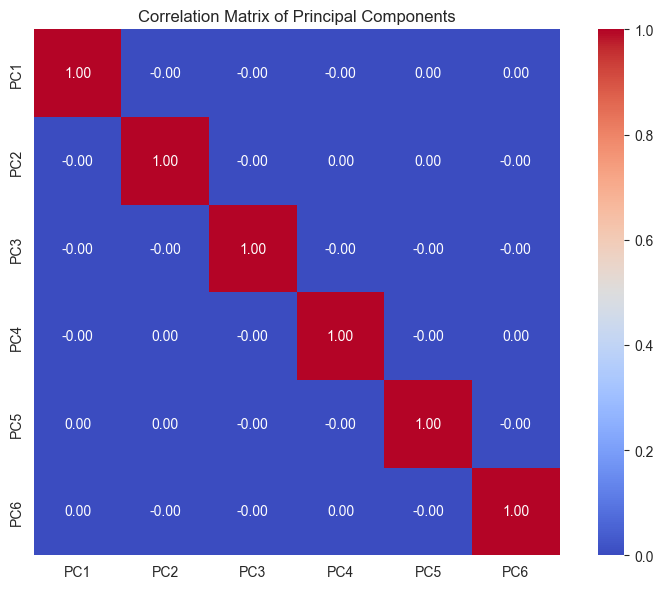

In [14]:
# todo
corr_pca = df_pca.corr()
print(corr_pca)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_pca, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Principal Components")
plt.tight_layout()
plt.savefig(
    r"pca_correlation_matrix.png")
plt.show()

## KMeans (45 points)
Implement kmeans from scratch.

In [15]:
import numpy as np


class CustomKMeans:
    def __init__(self, n_clusters=3, max_iter=100, random_state=42):
        """
        Initialize the KMeans class with the number of clusters and maximum iterations.
        n_clusters: Number of clusters to form.
        max_iter: Maximum number of iterations for convergence.
        random_state: Seed for reproducibility.
        """
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.centroids = None  # To store the centroids of clusters
        self.inertia_ = None  # To store the inertia (within-cluster sum of squares)
        self.labels_ = None  # To store the label assigned to each data point (cluster assignment)

    def fit(self, X):
        """
        Fit the KMeans model on the dataset X.
        X: Input data (n_samples, n_features)
        """
        X = np.array(X)
        n_samples, n_features = X.shape

        # Initialize centroids by randomly picking n_clusters data points
        rng = np.random.RandomState(self.random_state)
        random_idx = rng.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[random_idx].copy()

        for _ in range(self.max_iter):
            # Step 1: Assign each point to the nearest centroid
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            labels = np.argmin(distances, axis=1)

            # Step 2: Recompute centroids as the mean of assigned points
            new_centroids = np.zeros_like(self.centroids)
            for k in range(self.n_clusters):
                cluster_points = X[labels == k]
                if len(cluster_points) > 0:
                    new_centroids[k] = cluster_points.mean(axis=0)
                else:
                    # Keep old centroid if a cluster lost all its points
                    new_centroids[k] = self.centroids[k]

            # Step 3: Check for convergence
            if np.allclose(new_centroids, self.centroids):
                self.centroids = new_centroids
                break

            self.centroids = new_centroids

        self.labels_ = labels
        self.inertia_ = self._calculate_inertia(X)

        return self

    def _calculate_inertia(self, X):
        """
        Calculate the within-cluster sum of squared distances (inertia).
        X: Input data (n_samples, n_features)
        Returns: inertia (float)
        """
        # Step 1: For each cluster, compute the squared distances of points from their corresponding centroid
        # Step 2: Sum all squared distances to compute inertia
        inertia = 0.0
        for k in range(self.n_clusters):
            cluster_points = X[self.labels_ == k]
            if len(cluster_points) > 0:
                inertia += np.sum((cluster_points - self.centroids[k]) ** 2)
        return inertia

### Elbow Method
Apply the elbow method to determine the optimal number of clusters for K-Means. what is the best number of clusters?

Looking at the WCSS curve, the inertia drops sharply from k=1 to about k=4,
then continues decreasing but at a much slower, steadily diminishing rate.
The most visible "elbow" — where the rate of decrease changes most
noticeably — occurs around k = 9 or k = 10, after which the curve becomes
nearly flat with only marginal reductions in WCSS for each additional
cluster. Based on this, the best number of clusters is approximately **k = 9**
(or k = 10), balancing model simplicity against explained within-cluster
variance.

In [16]:
# Initialize an empty list to store the WCSS values for each number of clusters
WCSS = []

# Apply KMeans for a range of cluster values (from 1 to 30)
for i in range(1, 30):
    # Initialize the CustomKMeans with `i` clusters and a random state of 42
    kmeans_pca = CustomKMeans(n_clusters=i, random_state=42)

    # Fit the model to the PCA-transformed data
    kmeans_pca.fit(df_pca.values)

    # Append the calculated inertia (WCSS) to the WCSS list
    WCSS.append(kmeans_pca.inertia_)

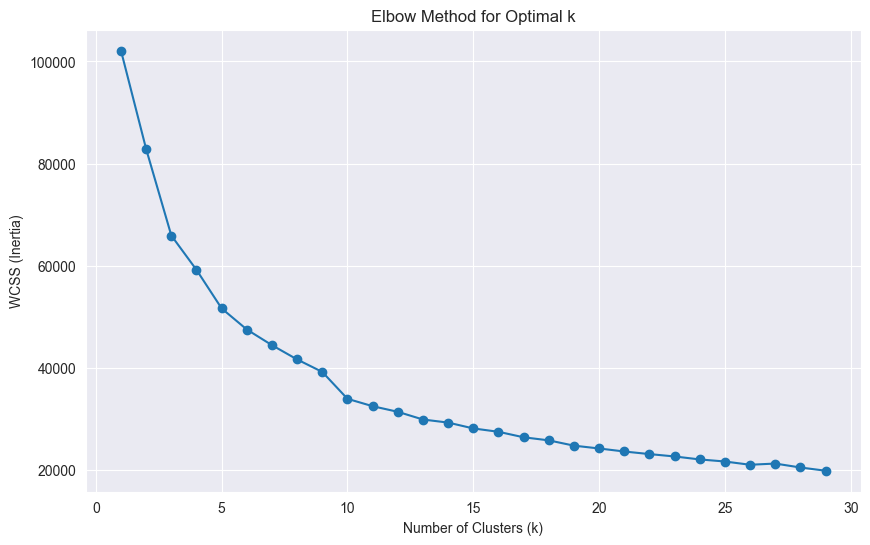

In [17]:
# Plot the Elbow curve using Matplotlib
plt.figure(figsize=(10, 6))
plt.plot(range(1, 30), WCSS, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.savefig(r"elbow_method.png")
plt.show()

Apply the optimal KMeans clustering on the PCA-transformed data, and assign cluster labels to each observation. Add a new column named segment to the df_pca DataFrame to store these labels.

In [18]:
# Apply KMeans on PCA-reduced data with the optimal number of clusters based on the elbow method
optimal_k = 9

kmeans_final = CustomKMeans(n_clusters=optimal_k, random_state=42)
kmeans_final.fit(df_pca.values)# Apply KMeans on PCA-reduced data with the optimal number of clusters based on the elbow method


In [19]:
# Add a new column 'segment' to pca data frame and assign the cluster labels to each observation
df_pca['segment'] = kmeans_final.labels_
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,segment
0,1.731242,0.824084,-0.384320,-0.451623,-0.087766,0.438057,5
1,0.301398,-2.533638,0.621582,-0.939313,-0.794456,0.060615,1
2,-1.194199,0.887568,-1.184455,1.129115,-1.152626,-1.869029,8
3,0.930140,0.030106,-0.111213,-1.309452,-0.505452,-0.834667,5
4,1.499511,0.517780,-0.794300,-0.125376,-0.253049,0.326998,5


 visualize the clustering by plotting the pairwise relationships of the PCA-reduced features, color-coded by the cluster assignments.

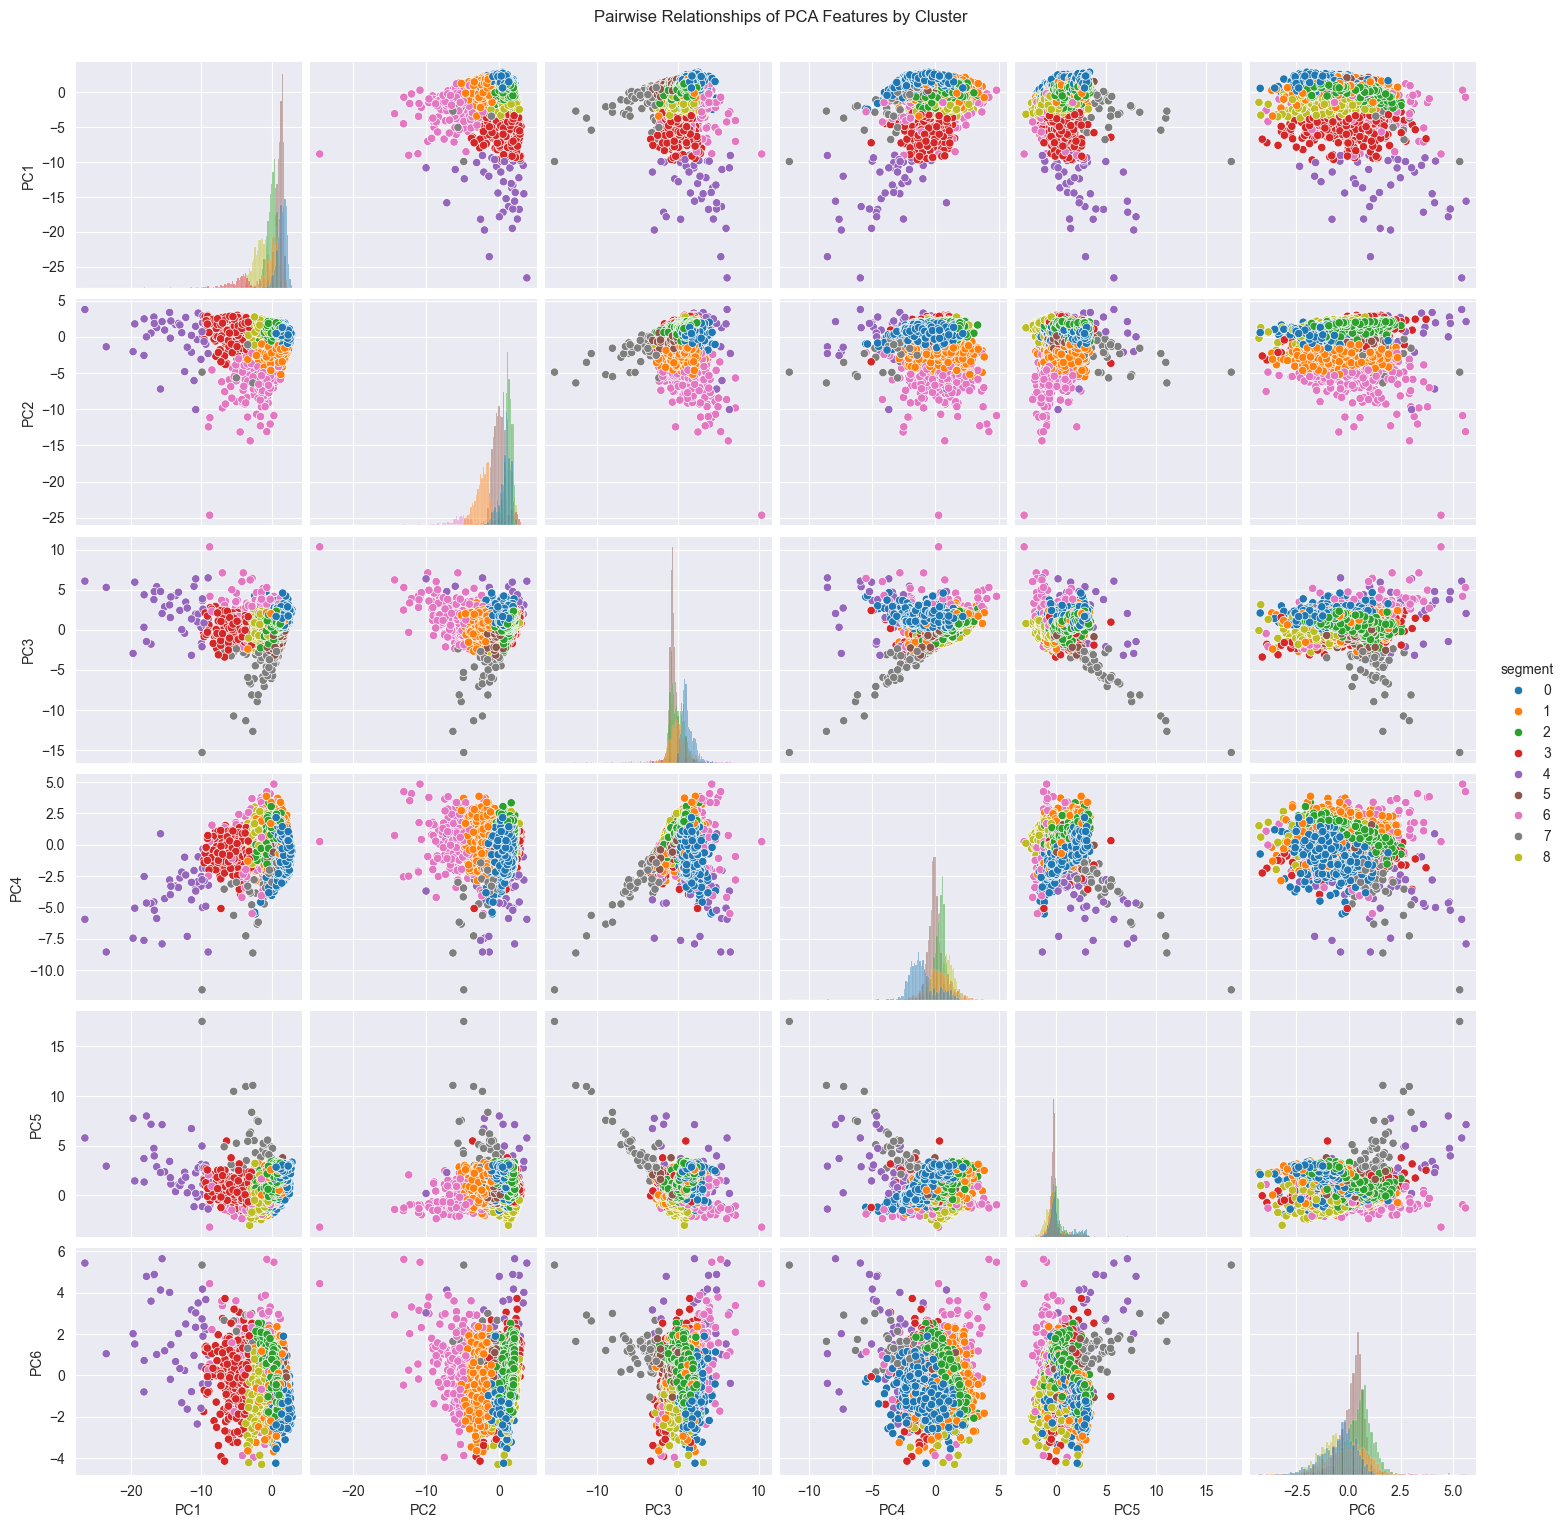

In [20]:
# todo
pca_cols = [c for c in df_pca.columns if c.startswith("PC")]
sns.pairplot(df_pca, vars=pca_cols, hue='segment', palette='tab10', diag_kind='hist')
plt.suptitle("Pairwise Relationships of PCA Features by Cluster", y=1.02)
plt.savefig(r"pca_pairplot_clusters.png", bbox_inches='tight')
plt.show()# todo

So, when we employ PCA prior to using K-means we can visually separate almost the entire data set. That was one of the biggest goals of PCA - to reduce the number of variables by combining them into bigger, more meaningful features.

### Hierarchical Clustering
Perform hierarchical clustering on the reduced dataset after PCA. Use complete linkage method.


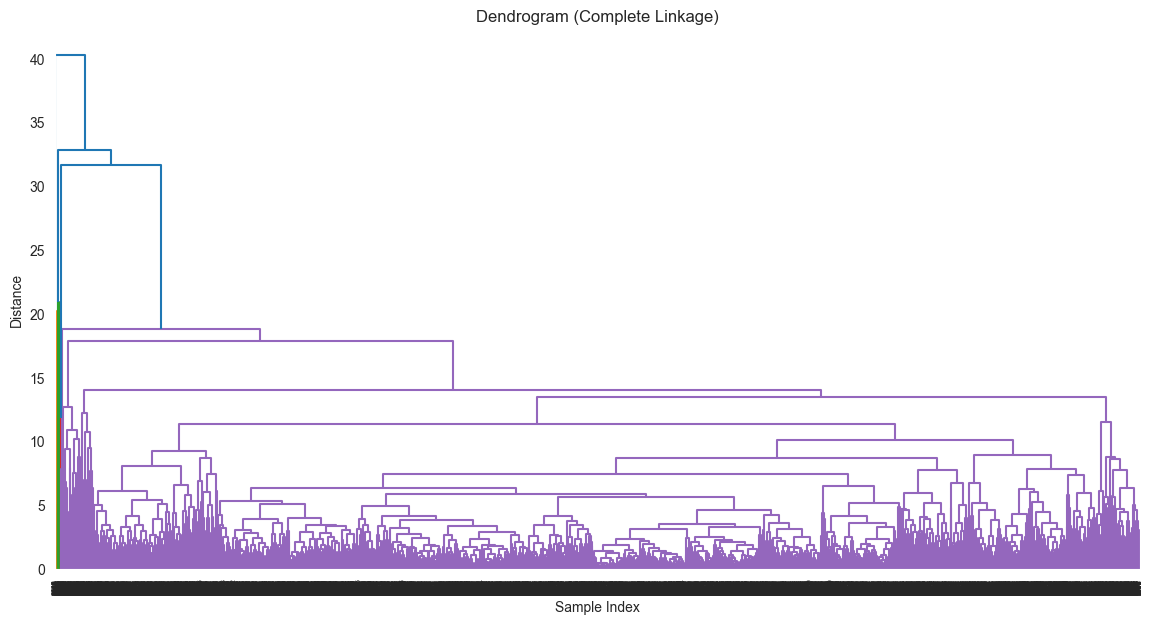

In [21]:
# Perform Hierarchical Clustering on the pca dataset
pca_features = df_pca.drop(columns=['segment'])
linkage_matrix = linkage(pca_features.values, method='complete')

# Visualize the dendrogram
plt.figure(figsize=(14, 7))
dendrogram(linkage_matrix)
plt.title("Dendrogram (Complete Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.savefig(r"dendrogram.png")
plt.show()


"Use scipy.cluster.hierarchy.fcluster to assign clusters from the dendrogram with a specified number of 5 clusters. Then visualize the results using pairplots.

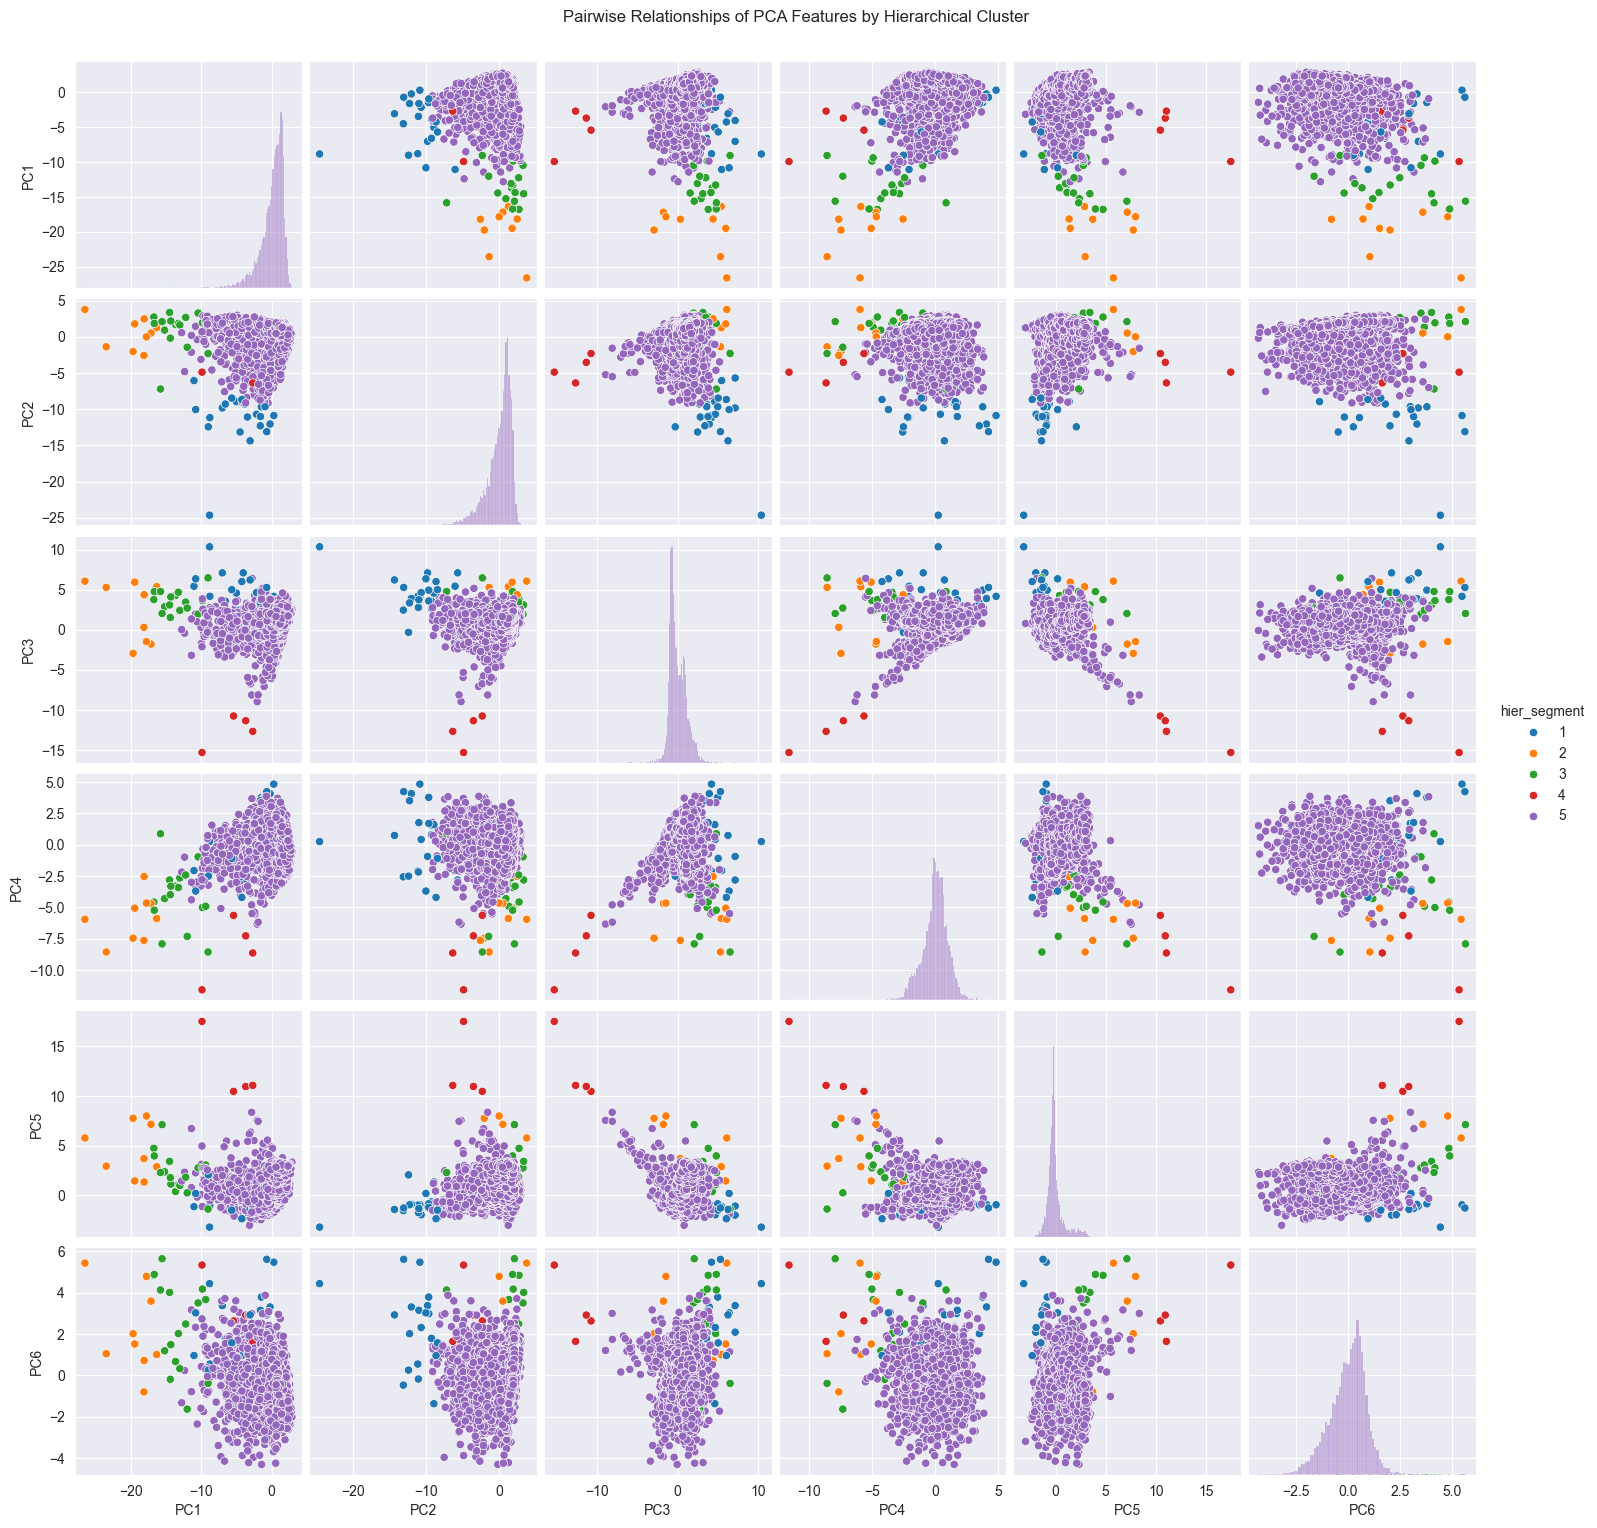

In [22]:
# Choose threshold and assign clusters
hier_labels = fcluster(linkage_matrix, t=5, criterion='maxclust')

# Assign cluster labels to PCA DataFrame
df_pca['hier_segment'] = hier_labels

# Visualize using PCA components
pca_cols = [c for c in df_pca.columns if c.startswith("PC")]
sns.pairplot(df_pca, vars=pca_cols, hue='hier_segment', palette='tab10', diag_kind='hist')
plt.suptitle("Pairwise Relationships of PCA Features by Hierarchical Cluster", y=1.02)
plt.savefig(r"hier_pairplot_clusters.png", bbox_inches='tight')
plt.show()